In [15]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_7cdc23c65e220f5584d40f70c44ff013'

In [16]:
import kagglehub

path = kagglehub.dataset_download("tunguz/big-five-personality-test")
print(path)

/home/angela/.cache/kagglehub/datasets/tunguz/big-five-personality-test/versions/1


In [17]:
import pandas as pd

df = pd.read_csv(f"{path}/IPIP-FFM-data-8Nov2018/data-final.csv", sep='\t')
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [18]:
df = df.replace(-1, 0)
df = df.fillna(0)

In [24]:
df = df.sample(n=10000, random_state=42)

df["EXT_TOTAL"] = df[
    ["EXT1", "EXT2", "EXT3", "EXT4", "EXT5", "EXT6", "EXT7", "EXT8", "EXT9", "EXT10"]
].mean(axis=1)

cols_to_drop = [col for col in df.columns if "EXT" in col] + [
    "screenw",
    "screenh",
    "introelapse",
    "testelapse",
    "endelapse",
    "IPC",
    "lat_appx_lots_of_err",
    "long_appx_lots_of_err",
    "dateload",
]

X = df.drop(cols_to_drop, axis=1)
X = X.select_dtypes(
    include=["number"]
)  

y = df["EXT_TOTAL"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
print(X.columns)
print(f"Number of features: {len(X.columns)}")

Index(['EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9',
       'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8',
       'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7',
       'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6',
       'OPN7', 'OPN8', 'OPN9', 'OPN10', 'EST1_E', 'EST2_E', 'EST3_E', 'EST4_E',
       'EST5_E', 'EST6_E', 'EST7_E', 'EST8_E', 'EST9_E', 'EST10_E', 'AGR1_E',
       'AGR2_E', 'AGR3_E', 'AGR4_E', 'AGR5_E', 'AGR6_E', 'AGR7_E', 'AGR8_E',
       'AGR9_E', 'AGR10_E', 'CSN1_E', 'CSN2_E', 'CSN3_E', 'CSN4_E', 'CSN5_E',
       'CSN6_E', 'CSN7_E', 'CSN8_E', 'CSN9_E', 'CSN10_E', 'OPN1_E', 'OPN2_E',
       'OPN3_E', 'OPN4_E', 'OPN5_E', 'OPN6_E', 'OPN7_E', 'OPN8_E', 'OPN9_E',
       'OPN10_E'],
      dtype='str')
Number of features: 80


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

In [29]:
from sklearn.metrics import mean_squared_error

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = mse
    print(f"{name} - MSE: {mse}")

Random Forest - MSE: 0.10184399873688824
Linear Regression - MSE: 0.10784507560862766
Decision Tree - MSE: 0.22522834710743803
KNN - MSE: 0.1319046


In [30]:
best_model = min(results, key=results.get)
print("\nMejor modelo:", best_model)


Mejor modelo: Random Forest


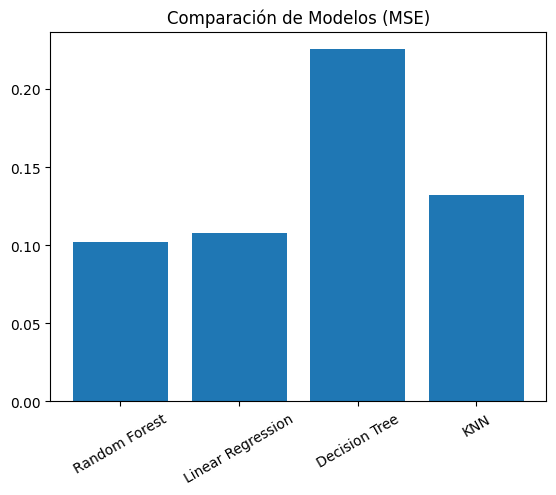

In [31]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Comparación de Modelos (MSE)")
plt.xticks(rotation=30)
plt.show()

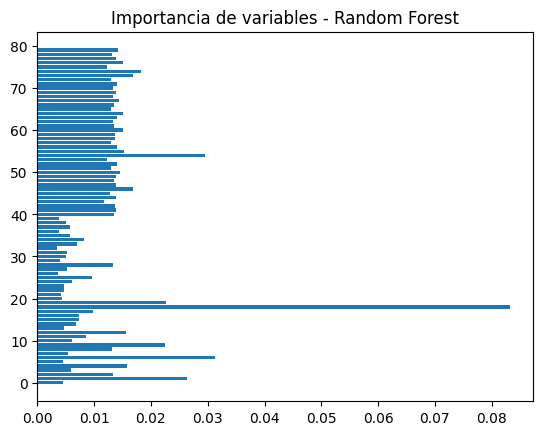

In [32]:
rf = models["Random Forest"]

importances = rf.feature_importances_

plt.barh(range(len(importances)), importances)
plt.title("Importancia de variables - Random Forest")
plt.show()

In [33]:
import joblib

# Get the best model object
best_model_object = models[best_model]

# Export the model
joblib.dump(best_model_object, 'best_model.pkl')

print(f"Modelo '{best_model}' exportado a best_model.pkl")

Modelo 'Random Forest' exportado a best_model.pkl
